# Analytic solutions for pseudo particle diagrams of one fermion

When considering a single fermion state hybridized with the environment by a hybridization function the diagram combinatorics is drastically simplified. 

With a single fermion, creation an annihilation operators must appear in an alternating sequence in order to give a non-zero result.

In combination with a hybridization function $\Delta(\tau)$ comprised of a single pole $\Delta(\tau) = K(\tau, \omega)$ (see below) and a diagonal pseudo particle Green's function being a single exponential decay, it is possible to analytically compute the integrals in the self-energy and single particle Green's function diagrams.

In [1]:
import sympy as sp

In [103]:
t, t1, t2, t3, t4 = sp.symbols(r'\tau \tau_1 \tau_2 \tau_3 \tau_4', positive=True)
b, w = sp.symbols(r'\beta \omega', nonzero=True)

## Fermi kernel

$$
K(\tau, \omega) = - \frac{e^{-\omega \tau}}{1 + e^{-\beta \omega}}
$$

for $\tau \in [0, \beta]$ the case of $-\beta < \tau < 0$ is given by the antiperiodic property $K(-\tau, \omega) \equiv - K(\beta - \tau, \omega) = - K(\tau, -\omega)$.

We will also make use of $K(\tau, \omega) = K(0, \omega) e^{-\omega \tau}$ in the integral relations below.

In [66]:
K = lambda t, w : -sp.exp(-w*t)/(1 + sp.exp(-b*w))
K(t, w)

-exp(-\omega*\tau)/(1 + exp(-\beta*\omega))

## Hybridization function

$$
\Delta(\tau) = K(\tau, \omega)
$$

with one fixed $\omega$.

## Pseudo particle Green's function

$$
G(\tau) = - e^{-\alpha \tau}
$$

with $\alpha = \ln(2) / \beta$, such that $G(\beta) = - \frac{1}{2}$.

Inserting $\alpha$ gives

$$
G(\tau) = - 2^{-\tau/\beta}
$$

In [102]:
G = -sp.exp(-sp.ln(2) / b * t).simplify()
G

-1/2**(\tau/\beta)

Note that this propagator obeys the chain relation (with odd number of terms)

$$
G(\tau - \tau_1)G(\tau_1 - \tau_2) \dots G(\tau_{2n-1} - \tau_{2n})G(\tau_{2n} - 0)
= G(\tau)
$$

In [155]:
Gprod = G.subs(t, t - t1)*G.subs(t, t1 - t2) * G.subs(t, t2 - 0)
Gprod

-1/(2**(\tau_2/\beta)*2**((\tau - \tau_1)/\beta)*2**((\tau_1 - \tau_2)/\beta))

In [156]:
Gprod = Gprod.simplify()
Gprod

-1/2**(\tau/\beta)

In [157]:
Gprod == G

True

## First order self-energy diagrams

$$
\Sigma_{0,0}(\tau) = -\Delta(-\tau) G(\tau) = K(\tau, -\omega) G(\tau)
$$

$$
\Sigma_{1, 1}(\tau) = \Delta(\tau) G(\tau) = K(\tau, \omega) G(\tau)
$$

In [104]:
Sigma_01_00 = K(t, -w) * G
Sigma_01_00

exp(\omega*\tau)/(2**(\tau/\beta)*(exp(\beta*\omega) + 1))

In [105]:
Sigma_01_11 = K(t, w) * G 
Sigma_01_11

exp(-\omega*\tau)/(2**(\tau/\beta)*(1 + exp(-\beta*\omega)))

## Second order self-energy diagrams

There are no non-zero diagrams since the second order diagram can not accomodate an alternating sequence of creation and annihilation operators.

## Third order self-energy diagrams

$$
\Sigma_{0,0}(\tau) =
\int_0^\tau d\tau_1 \int_0^{\tau_1} d\tau_2 
\int_0^{\tau_2} d\tau_3 \int_0^{\tau_3} d\tau_4
$$
$$
\Delta(\tau_3 - \tau) \Delta(\tau_1 - \tau_4) \Delta(0 - \tau_2)
$$
$$
G(\tau - \tau_1)G(\tau_1 - \tau_2)G(\tau_2 - \tau_3)
G(\tau_3 - \tau_4)G(\tau_4 - 0)
$$

$$
=
e^{-\alpha \tau}
\int_0^\tau d\tau_1 \int_0^{\tau_1} d\tau_2 
\int_0^{\tau_2} d\tau_3 \int_0^{\tau_3} d\tau_4 \,
K(\tau - \tau_3, -\omega) K(\tau_1 - \tau_4, \omega) K(\tau_2, -\omega) 
$$

$$
=
e^{-\alpha \tau} K^2(0, -\omega) K(0, \omega)
\int_0^\tau d\tau_1 \int_0^{\tau_1} d\tau_2 
\int_0^{\tau_2} d\tau_3 \int_0^{\tau_3} d\tau_4 \,
e^{\omega(\tau - \tau_3)} e^{-\omega(\tau_1 - \tau_4)} e^{\omega \tau_2}
$$

$$
=
e^{-\alpha \tau} K^2(0, -\omega) K(0, \omega)
\int_0^\tau d\tau_1 \int_0^{\tau_1} d\tau_2 
\int_0^{\tau_2} d\tau_3 \int_0^{\tau_3} d\tau_4 \,
e^{\omega(\tau - \tau_1 + \tau_2 - \tau_3 + \tau_4)}
$$

In [121]:
I4 = sp.integrate(sp.exp(+w*t4), (t4, 0, t3))
I3 = sp.integrate(sp.exp(-w*t3) * I4, (t3, 0, t2)) 
I2 = sp.integrate(sp.exp(+w*t2) * I3, (t2, 0, t1)).simplify()
I1 = sp.integrate(sp.exp(-w*t1) * I2, (t1, 0, t))

Sigma_031425_00 = G * K(0, -w)**2 * K(0, w) * sp.exp(w*t) * I1
Sigma_031425_00.simplify()

(\omega**2*\tau**2*exp(\omega*\tau) - 4*\omega*\tau*exp(\omega*\tau) - 2*\omega*\tau + 6*exp(\omega*\tau) - 6)*exp(\beta*\omega)/(2*2**(\tau/\beta)*\omega**4*(exp(\beta*\omega) + 1)**3)

Switching the direction of all hybridization functions gives the $\Sigma_{1, 1}$ diagram

$$
\Sigma_{1, 1}(\tau)
=
e^{-\alpha \tau} K^2(0, \omega) K(0, -\omega)
\int_0^\tau d\tau_1 \int_0^{\tau_1} d\tau_2 
\int_0^{\tau_2} d\tau_3 \int_0^{\tau_3} d\tau_4 \,
e^{\omega(-\tau + \tau_1 - \tau_2 + \tau_3 - \tau_4)}
$$

In [122]:
I4 = sp.integrate(sp.exp(-w*t4), (t4, 0, t3))
I3 = sp.integrate(sp.exp(+w*t3) * I4, (t3, 0, t2)) 
I2 = sp.integrate(sp.exp(-w*t2) * I3, (t2, 0, t1)).simplify()
I1 = sp.integrate(sp.exp(+w*t1) * I2, (t1, 0, t))

Sigma_031425_11 = G * K(0, w)**2 * K(0, -w) * sp.exp(-w*t) * I1
Sigma_031425_11.simplify()

(\omega**2*\tau**2 + 4*\omega*\tau + 2*(\omega*\tau - 3)*exp(\omega*\tau) + 6)*exp(\omega*(2*\beta - \tau))/(2*2**(\tau/\beta)*\omega**4*(exp(\beta*\omega) + 1)**3)

## Third order single particle Green's function diagram

Since the single particle Green's function $g(\tau) = -\langle \mathcal{T} c(\tau) c^\dagger(0) \rangle$ sets the operator of the $\tau = 0$ vertex to be $c^\dagger$. This causes only the empty state $|0\rangle$ to contribute in the outer trace over many-body states, and thus we only have a single non-zero third order diagram (among the possible forward/backward combinations) in the topology [(0,3), (1,4), (2, 5)].

$$
g_3(\tau) =
\int_\tau^\beta d\tau_1 \int_\tau^{\tau_1} d\tau_2
\int_0^\tau d\tau_3 \int_0^{\tau_3} d\tau_4
$$
$$
\Delta(\tau_3 - \tau_1) \Delta(\tau_2 - \tau_4)
$$
$$
G(\beta - \tau_1)G(\tau_1 - \tau_2)G(\tau_2 - \tau)
G(\tau - \tau_3)G(\tau_3 - \tau_4)G(\tau_4 - 0)
$$

$$
= 
- G(\beta) K(0, \omega) K(0, -\omega)
\int_\tau^\beta d\tau_1 \int_\tau^{\tau_1} d\tau_2
\int_0^\tau d\tau_3 \int_0^{\tau_3} d\tau_4
e^{\omega(\tau_1 - \tau_3)} e^{-\omega(\tau_2 - \tau_4)}
$$

$$
= 
\frac{1}{2} K(0, \omega) K(0, -\omega)
\left[ 
\int_\tau^\beta d\tau_1 \int_\tau^{\tau_1} d\tau_2
e^{\omega(\tau_1 - \tau_2)}
\right] 
\left[
\int_0^\tau d\tau_3 \int_0^{\tau_3} d\tau_4
e^{\omega(-\tau_3 + \tau_4)}
\right]
$$

In [141]:
IL = sp.integrate(sp.exp(w*(t1 - t2)), (t2, t, t1), (t1, t, b))
IR = sp.integrate(sp.exp(w*(-t3 + t4)), (t4, 0, t3), (t3, 0, t))

spgf_031425 = K(0, w) * K(0, -w) * IL * IR / 2
spgf_031425

(\tau/\omega - 1/\omega**2 + exp(-\omega*\tau)/\omega**2)*(-\beta/\omega + \tau/\omega + exp(\omega*(\beta - \tau))/\omega**2 - 1/\omega**2)/(2*(1 + exp(-\beta*\omega))*(exp(\beta*\omega) + 1))

# Visualization

In [108]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import matplotlib.pyplot as plt
import numpy as np

In [109]:
beta = 1.0
omega = 0.1
alpha = np.log(2) / beta

tau = np.linspace(0, beta, num=40)

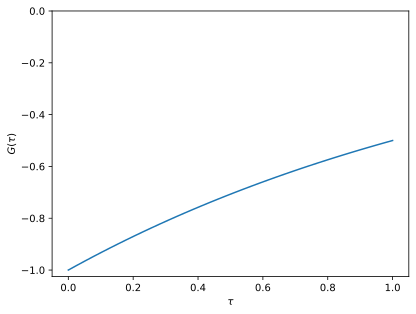

In [111]:
Gfunc = sp.lambdify([t, b], G)
plt.plot(tau, Gfunc(tau, beta))
plt.xlabel(r'$\tau$')
plt.ylabel(r'$G(\tau)$')
plt.ylim(top=0);

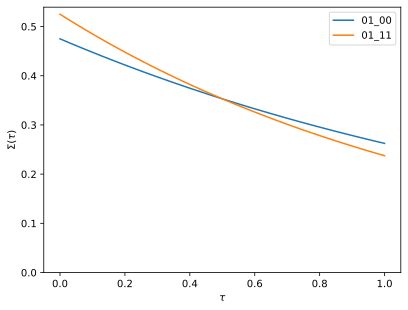

In [113]:
Sfunc_01_00 = sp.lambdify([t, b, w], Sigma_01_00)
Sfunc_01_11 = sp.lambdify([t, b, w], Sigma_01_11)

plt.plot(tau, Sfunc_01_00(tau, beta, omega), label='01_00')
plt.plot(tau, Sfunc_01_11(tau, beta, omega), label='01_11')

plt.legend(loc='best')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Sigma(\tau)$')
plt.ylim(bottom=0);

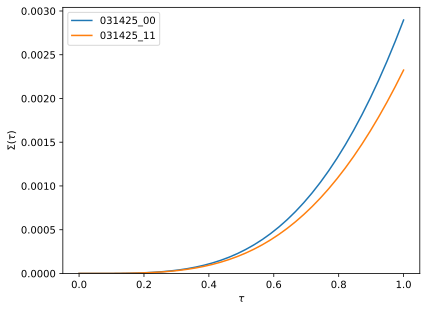

In [114]:
Sfunc_031425_00 = sp.lambdify([t, b, w], Sigma_031425_00)
Sfunc_031425_11 = sp.lambdify([t, b, w], Sigma_031425_11)

plt.plot(tau, Sfunc_031425_00(tau, beta, omega), label='031425_00')
plt.plot(tau, Sfunc_031425_11(tau, beta, omega), label='031425_11')

plt.legend(loc='best')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Sigma(\tau)$')
plt.ylim(bottom=0);

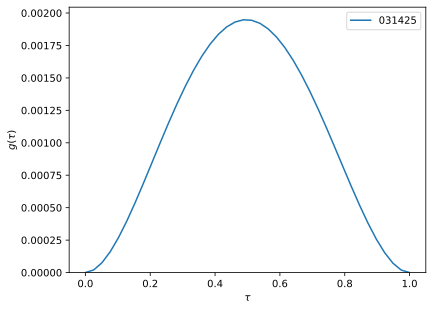

In [142]:
spgf_func_031425 = sp.lambdify([t, b, w], spgf_031425)

plt.plot(tau, spgf_func_031425(tau, beta, omega), label='031425')

plt.legend(loc='best')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$g(\tau)$')
plt.ylim(bottom=0);